## Looking to see how assists change during certain situations

In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
s20 = pd.read_parquet("/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2019-20/regular_season/player_gamelogs.parquet")
s21 = pd.read_parquet("/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2020-21/regular_season/player_gamelogs.parquet")
s22 = pd.read_parquet("/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2021-22/regular_season/player_gamelogs.parquet")
s23 = pd.read_parquet("/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2022-23/regular_season/player_gamelogs.parquet")
s24 = pd.read_parquet("/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2023-24/regular_season/player_gamelogs.parquet")
s25 = pd.read_parquet("/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2024-25/regular_season/player_gamelogs.parquet")
s26 = pd.read_parquet("/Users/alexgonzalez/Documents/nba_quant/data/silver/nba/2025-26/regular_season/player_gamelogs.parquet")
df = pd.concat([s20, s21, s22, s23, s24, s25, s26])
print(f"Number of rows: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
df.sample(5)

Number of rows: 176738
Number of columns: 189


,season_year,player_id,player_name,nickname,team_id,team_abbreviation,team_name,game_id,game_date,matchup,...,opp_e_pace,opp_pace,opp_pace_per40,opp_poss,opp_pie,season_type,pos,game_total,team_spread,player_team_spread
18599,2020-21,1628969,Mikal Bridges,Mikal,1610612756,PHX,Phoenix Suns,0022000222,2021-01-20T00:00:00,PHX @ HOU,...,106.5,105.0,87.50,104,0.446,Regular Season,SF,219.0,5.5,-5.5
10816,2019-20,1628989,Kevin Huerter,Kevin,1610612737,ATL,Atlanta Hawks,0021900543,2020-01-06T00:00:00,ATL vs. DEN,...,99.0,95.0,79.17,95,0.542,Regular Season,SG,224.0,7.0,7.0
22731,2020-21,203145,Kent Bazemore,Kent,1610612744,GSW,Golden State Warriors,0022000006,2020-12-25T00:00:00,GSW @ MIL,...,109.7,109.5,91.25,110,0.714,Regular Season,SF,230.5,-10.0,10.0
13915,2025-26,1628970,Miles Bridges,Miles,1610612766,CHA,Charlotte Hornets,0022500563,2026-01-12T00:00:00,CHA @ LAC,...,96.4,94.0,78.33,94,0.494,Regular Season,PF,222.5,-4.5,4.5
9729,2020-21,1629671,Miye Oni,Miye,1610612762,UTA,Utah Jazz,0022000656,2021-03-22T00:00:00,UTA @ CHI,...,99.4,98.0,81.67,98,0.384,Regular Season,SG,227.5,9.5,-9.5


In [4]:
# Helpers
starter = df["start_position"].astype("string").str.strip()
df["starting"] = starter.isin(["G", "F", "C"]).astype(int)

MINUTE_BINS = [0.0, 12.0, 18.0, 24.0, 30.0, 36.0, 64.0]
MINUTE_LABELS = ["[0, 12)", "[12, 18)", "[18, 24)", "[24, 30)", "[30, 36)", "[36, 64)"]
df["minutes"] = pd.to_numeric(df["minutes"], errors="coerce")
df["ast"] = pd.to_numeric(df["ast"], errors="coerce")
df["minute_band"] = pd.cut(
    df["minutes"],
    bins=MINUTE_BINS,
    labels=MINUTE_LABELS,
    right=False,
    include_lowest=True,
).astype("string")
df["ast_per_min"] = np.where(df["minutes"] > 0, df["ast"] / df["minutes"], np.nan)
df["starting"].value_counts(dropna=False)

starting
0    93848
1    82890
Name: count, dtype: int64

In [5]:
starting = df[df["starting"] == 1]
bench = df[df["starting"] == 0]
pd.concat(
    {
        "starting": starting["ast"].describe(),
        "bench": bench["ast"].describe(),
    },
    axis=1,
)

,starting,bench
count,82890.000000,93848.000000
mean,3.529485,1.409598
std,2.942164,1.714844
min,0.000000,0.000000
25%,1.000000,0.000000
50%,3.000000,1.000000
75%,5.000000,2.000000
max,24.000000,17.000000


### Assists by role and minutes

minute_band,"[0, 12)","[12, 18)","[18, 24)","[24, 30)","[30, 36)","[36, 64)"
role,,,,,,
starter,0.66,1.24,1.91,2.88,3.95,5.09
bench,0.44,1.27,1.91,2.53,3.21,3.46


minute_band,"[0, 12)","[12, 18)","[18, 24)","[24, 30)","[30, 36)","[36, 64)"
role,,,,,,
starter,0.083,0.079,0.089,0.105,0.119,0.132
bench,0.074,0.084,0.091,0.095,0.100,0.091


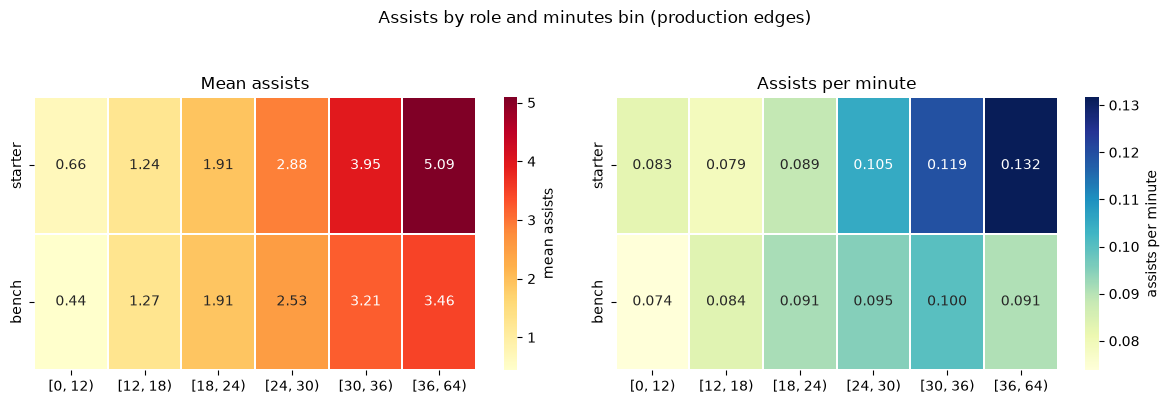

In [6]:
role_minutes = df.assign(
    role=np.where(df["starting"].eq(1), "starter", "bench"),
    pos=df["pos"].astype("string"),
)
role_minutes = role_minutes.loc[role_minutes["minute_band"].isin(MINUTE_LABELS)]

assists_by_role_minutes = (
    role_minutes.groupby(["role", "minute_band"], observed=False)["ast"]
    .agg(mean="mean", median="median", rows="size")
    .reset_index()
)
means = (
    assists_by_role_minutes.pivot(index="role", columns="minute_band", values="mean")
    .reindex(index=["starter", "bench"], columns=MINUTE_LABELS)
)
rates = (
    role_minutes.groupby(["role", "minute_band"], observed=False)["ast_per_min"]
    .mean()
    .unstack("minute_band")
    .reindex(index=["starter", "bench"], columns=MINUTE_LABELS)
)
display(means.round(2))
display(rates.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
sns.heatmap(
    means,
    ax=axes[0],
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    linewidths=0.3,
    cbar_kws={"label": "mean assists"},
)
axes[0].set_title("Mean assists")
axes[0].set_xlabel("")
axes[0].set_ylabel("")
sns.heatmap(
    rates,
    ax=axes[1],
    cmap="YlGnBu",
    annot=True,
    fmt=".3f",
    linewidths=0.3,
    cbar_kws={"label": "assists per minute"},
)
axes[1].set_title("Assists per minute")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
fig.suptitle("Assists by role and minutes bin (production edges)", y=1.05)
plt.tight_layout()
plt.show()

### First we will look at starters

In [7]:
starter_assists_by_slot = starting.groupby(
    starting["start_position"].astype("string").str.strip(),
    dropna=False,
)["ast"].describe().T
starter_assists_by_pos = starting.groupby("pos", dropna=False)["ast"].describe().T

starter_assists_by_slot = starter_assists_by_slot.reindex(
    columns=["G", "F", "C"],
)
starter_assists_by_pos = starter_assists_by_pos.reindex(
    columns=["PG", "SG", "SF", "PF", "C"],
)

display(starter_assists_by_slot)
display(starter_assists_by_pos)

start_position,G,F,C
count,33156.000000,33156.000000,16578.000000
mean,4.810291,2.784232,2.458379
std,3.208075,2.368435,2.437414
min,0.000000,0.000000,0.000000
25%,2.000000,1.000000,1.000000
50%,4.000000,2.000000,2.000000
75%,7.000000,4.000000,3.000000
max,24.000000,20.000000,22.000000


pos,PG,SG,SF,PF,C
count,15619.000000,18099.000000,15971.000000,16397.000000,16796.000000
mean,6.234458,3.455440,2.797633,2.901628,2.403548
std,3.300402,2.532547,2.306208,2.477446,2.378563
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,2.000000,1.000000,1.000000,1.000000
50%,6.000000,3.000000,2.000000,2.000000,2.000000
75%,8.000000,5.000000,4.000000,4.000000,3.000000
max,24.000000,18.000000,16.000000,20.000000,22.000000


### Starter assists by position and minutes

minute_band,"[0, 12)","[12, 18)","[18, 24)","[24, 30)","[30, 36)","[36, 64)"
count,966.000000,2858.000000,9972.000000,21716.000000,30125.000000,17245.000000
mean,0.662526,1.236179,1.915062,2.875345,3.952564,5.089185
std,0.957102,1.351645,1.820416,2.412661,2.891772,3.357850
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,1.000000,2.000000,3.000000
50%,0.000000,1.000000,1.000000,2.000000,3.000000,5.000000
75%,1.000000,2.000000,3.000000,4.000000,6.000000,7.000000
max,7.000000,11.000000,15.000000,18.000000,23.000000,24.000000


minute_band,"[0, 12)","[12, 18)","[18, 24)","[24, 30)","[30, 36)","[36, 64)"
pos,,,,,,
PG,1.38,2.56,3.77,5.24,6.54,7.80
SG,0.72,1.29,1.89,2.81,3.75,4.77
SF,0.56,1.11,1.58,2.28,3.11,3.81
PF,0.51,0.99,1.66,2.41,3.24,4.04
C,0.53,1.01,1.52,2.12,2.96,4.15


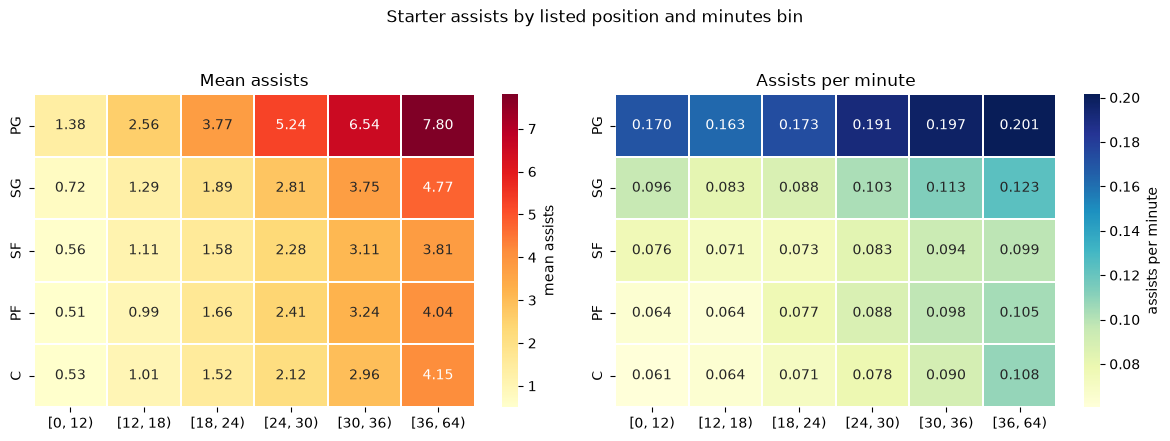

In [8]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
starter_minutes = starting.assign(
    pos=starting["pos"].astype("string"),
    minute_band=starting["minute_band"].astype("string"),
)
starter_minutes = starter_minutes.loc[
    starter_minutes["pos"].isin(pos_order)
    & starter_minutes["minute_band"].isin(MINUTE_LABELS)
]

starter_assists_by_minutes = (
    starter_minutes.groupby("minute_band", dropna=False)["ast"]
    .describe()
    .T
    .reindex(columns=MINUTE_LABELS)
)
assists_by_pos_minutes = (
    starter_minutes.groupby(["pos", "minute_band"], observed=False)["ast"]
    .mean()
    .unstack("minute_band")
    .reindex(index=pos_order, columns=MINUTE_LABELS)
)
rate_by_pos_minutes = (
    starter_minutes.groupby(["pos", "minute_band"], observed=False)["ast_per_min"]
    .mean()
    .unstack("minute_band")
    .reindex(index=pos_order, columns=MINUTE_LABELS)
)
display(starter_assists_by_minutes)
display(assists_by_pos_minutes.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.heatmap(
    assists_by_pos_minutes,
    ax=axes[0],
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    linewidths=0.3,
    cbar_kws={"label": "mean assists"},
)
axes[0].set_title("Mean assists")
axes[0].set_xlabel("")
axes[0].set_ylabel("")
sns.heatmap(
    rate_by_pos_minutes,
    ax=axes[1],
    cmap="YlGnBu",
    annot=True,
    fmt=".3f",
    linewidths=0.3,
    cbar_kws={"label": "assists per minute"},
)
axes[1].set_title("Assists per minute")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
fig.suptitle("Starter assists by listed position and minutes bin", y=1.04)
plt.tight_layout()
plt.show()

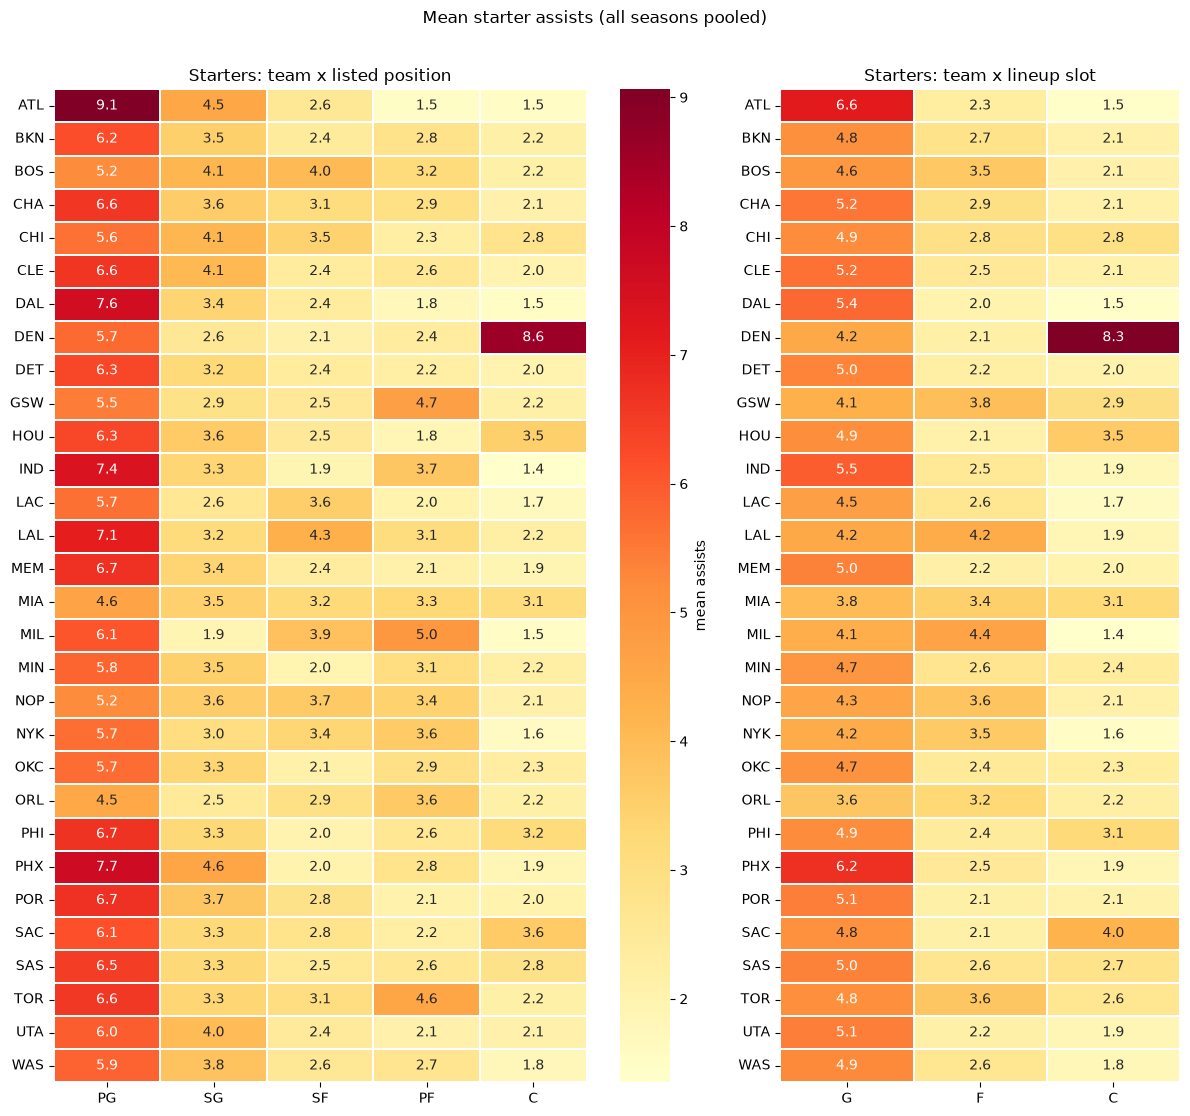

In [9]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
slot_order = ["G", "F", "C"]

starter_pos = starting.assign(
    pos=starting["pos"].astype("string"),
    start_slot=starting["start_position"].astype("string").str.strip(),
)

assists_by_team_pos = (
    starter_pos.loc[starter_pos["pos"].isin(pos_order)]
    .groupby(["team_abbreviation", "pos"], observed=False)["ast"]
    .mean()
    .unstack("pos")
    .reindex(columns=pos_order)
    .sort_index()
)
assists_by_team_slot = (
    starter_pos.loc[starter_pos["start_slot"].isin(slot_order)]
    .groupby(["team_abbreviation", "start_slot"], observed=False)["ast"]
    .mean()
    .unstack("start_slot")
    .reindex(columns=slot_order)
    .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 11), gridspec_kw={"width_ratios": [5, 3]})
sns.heatmap(
    assists_by_team_pos,
    ax=axes[0],
    cmap="YlOrRd",
    annot=True,
    fmt=".1f",
    linewidths=0.3,
    cbar_kws={"label": "mean assists"},
)
axes[0].set_title("Starters: team x listed position")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

sns.heatmap(
    assists_by_team_slot,
    ax=axes[1],
    cmap="YlOrRd",
    annot=True,
    fmt=".1f",
    linewidths=0.3,
    cbar=False,
)
axes[1].set_title("Starters: team x lineup slot")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
fig.suptitle("Mean starter assists (all seasons pooled)", y=1.01)
plt.tight_layout()
plt.show()

inference:

spread_role,≤ -7.5,-7.5 to -3,-3 to 3.5,> 3.5
pos,,,,
PG,6.54,6.55,6.22,5.86
SG,3.60,3.41,3.53,3.35
SF,3.02,2.79,2.76,2.71
PF,3.23,3.11,2.89,2.63
C,2.71,2.58,2.29,2.22


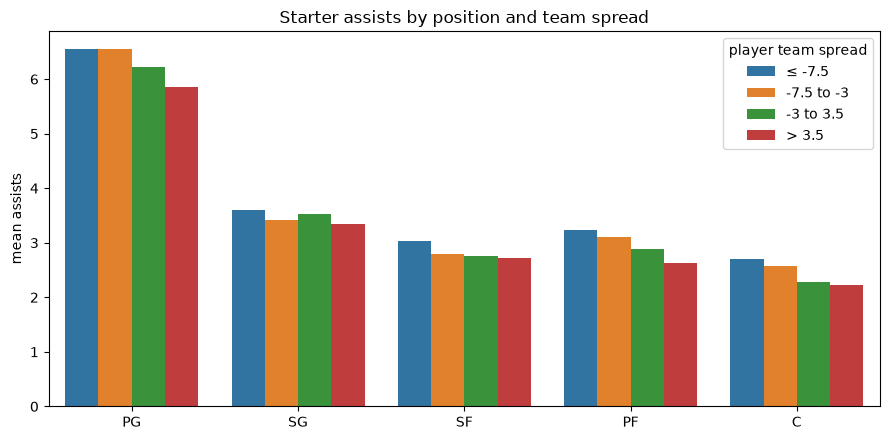

In [10]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
spread_order = ["≤ -7.5", "-7.5 to -3", "-3 to 3.5", "> 3.5"]
spread = pd.to_numeric(starting["player_team_spread"], errors="coerce")
starter_script = starting.assign(
    pos=starting["pos"].astype("string"),
    spread_role=pd.cut(
        spread,
        bins=[-np.inf, -7.5, -3, 3.5, np.inf],
        labels=spread_order,
        right=True,
    ).astype("string"),
)
starter_script = starter_script.loc[
    starter_script["pos"].isin(pos_order)
    & starter_script["spread_role"].isin(spread_order)
]

assists_by_pos_script = (
    starter_script.groupby(["pos", "spread_role"], observed=False)["ast"]
    .agg(mean="mean", median="median", rows="size")
    .reset_index()
)
means = (
    assists_by_pos_script.pivot(index="pos", columns="spread_role", values="mean")
    .reindex(index=pos_order, columns=spread_order)
)
display(means.round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(
    data=assists_by_pos_script,
    x="pos",
    y="mean",
    hue="spread_role",
    order=pos_order,
    hue_order=spread_order,
    ax=ax,
)
ax.set_title("Starter assists by position and team spread")
ax.set_xlabel("")
ax.set_ylabel("mean assists")
ax.legend(title="player team spread")
plt.tight_layout()
plt.show()

total_band,≤ 221,221–227,227.5–233.5,≥ 234
pos,,,,
PG,5.75,6.20,6.34,6.89
SG,3.30,3.39,3.52,3.66
SF,2.77,2.80,2.86,2.78
PF,2.82,2.87,2.92,3.08
C,2.28,2.27,2.39,2.78


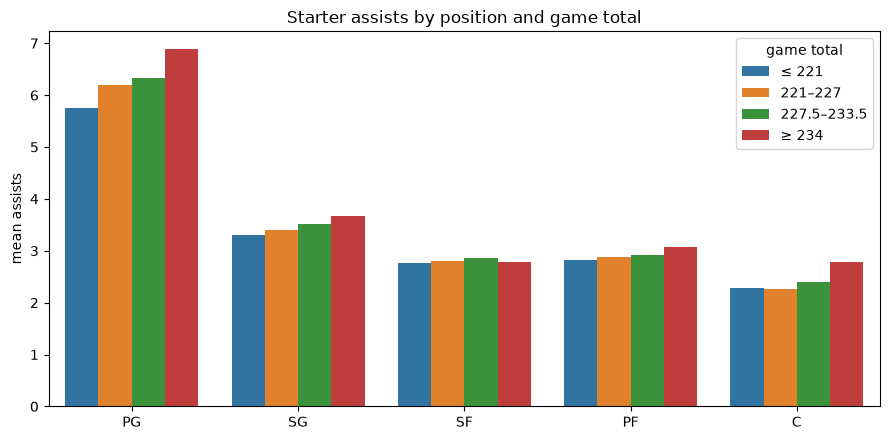

In [11]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
total_order = ["≤ 221", "221–227", "227.5–233.5", "≥ 234"]
game_total = pd.to_numeric(starting["game_total"], errors="coerce")
starter_total = starting.assign(
    pos=starting["pos"].astype("string"),
    total_band=pd.cut(
        game_total,
        bins=[-np.inf, 221, 227, 233.5, np.inf],
        labels=total_order,
        right=True,
    ).astype("string"),
)
starter_total = starter_total.loc[
    starter_total["pos"].isin(pos_order)
    & starter_total["total_band"].isin(total_order)
]

assists_by_pos_total = (
    starter_total.groupby(["pos", "total_band"], observed=False)["ast"]
    .agg(mean="mean", median="median", rows="size")
    .reset_index()
)
means = (
    assists_by_pos_total.pivot(index="pos", columns="total_band", values="mean")
    .reindex(index=pos_order, columns=total_order)
)
display(means.round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(
    data=assists_by_pos_total,
    x="pos",
    y="mean",
    hue="total_band",
    order=pos_order,
    hue_order=total_order,
    ax=ax,
)
ax.set_title("Starter assists by position and game total")
ax.set_xlabel("")
ax.set_ylabel("mean assists")
ax.legend(title="game total")
plt.tight_layout()
plt.show()

rest_band,B2B,2,3,3+
pos,,,,
PG,6.15,6.23,6.39,6.22
SG,3.37,3.49,3.41,3.48
SF,2.69,2.79,2.89,2.96
PF,2.79,2.90,3.05,2.90
C,2.39,2.41,2.43,2.38


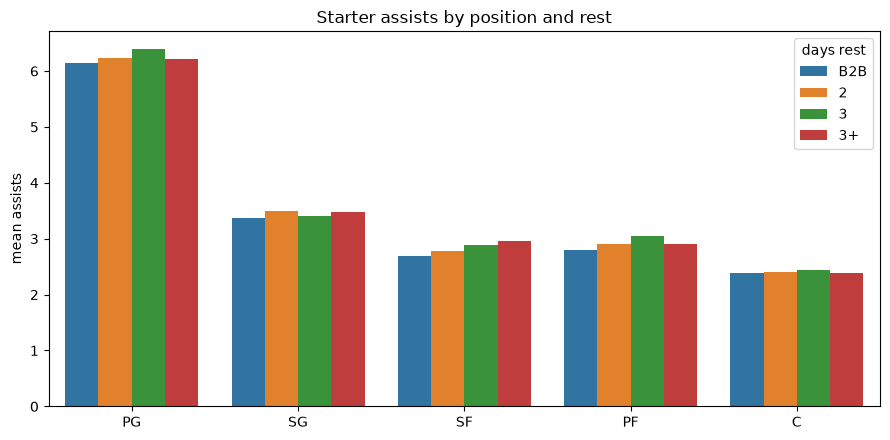

In [12]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
rest_order = ["B2B", "2", "3", "3+"]

rest = df.copy()
rest["game_date"] = pd.to_datetime(rest["game_date"])
rest = rest.sort_values(["player_id", "season_year", "game_date"], kind="stable")
rest["days_rest"] = (
    rest.groupby(["player_id", "season_year"], sort=False)["game_date"]
    .diff()
    .dt.days
)
rest["rest_band"] = np.select(
    [
        rest["days_rest"].eq(1),
        rest["days_rest"].eq(2),
        rest["days_rest"].eq(3),
        rest["days_rest"].ge(4),
    ],
    rest_order,
    default="other",
)

starter_rest = rest.loc[rest["starting"].eq(1)].assign(
    pos=lambda frame: frame["pos"].astype("string"),
)
starter_rest = starter_rest.loc[
    starter_rest["pos"].isin(pos_order)
    & starter_rest["rest_band"].isin(rest_order)
]

assists_by_pos_rest = (
    starter_rest.groupby(["pos", "rest_band"], observed=False)["ast"]
    .agg(mean="mean", median="median", rows="size")
    .reset_index()
)
means = (
    assists_by_pos_rest.pivot(index="pos", columns="rest_band", values="mean")
    .reindex(index=pos_order, columns=rest_order)
)
display(means.round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(
    data=assists_by_pos_rest,
    x="pos",
    y="mean",
    hue="rest_band",
    order=pos_order,
    hue_order=rest_order,
    ax=ax,
)
ax.set_title("Starter assists by position and rest")
ax.set_xlabel("")
ax.set_ylabel("mean assists")
ax.legend(title="days rest")
plt.tight_layout()
plt.show()

rest_band,B2B,2,3,3+
season_year,,,,
2019-20,3.18,3.29,3.27,3.28
2020-21,3.29,3.42,3.59,3.37
2021-22,3.37,3.43,3.51,3.58
2022-23,3.46,3.53,3.69,3.64
2023-24,3.64,3.76,3.77,3.81
2024-25,3.57,3.67,3.79,3.66
2025-26,3.48,3.61,3.61,3.57


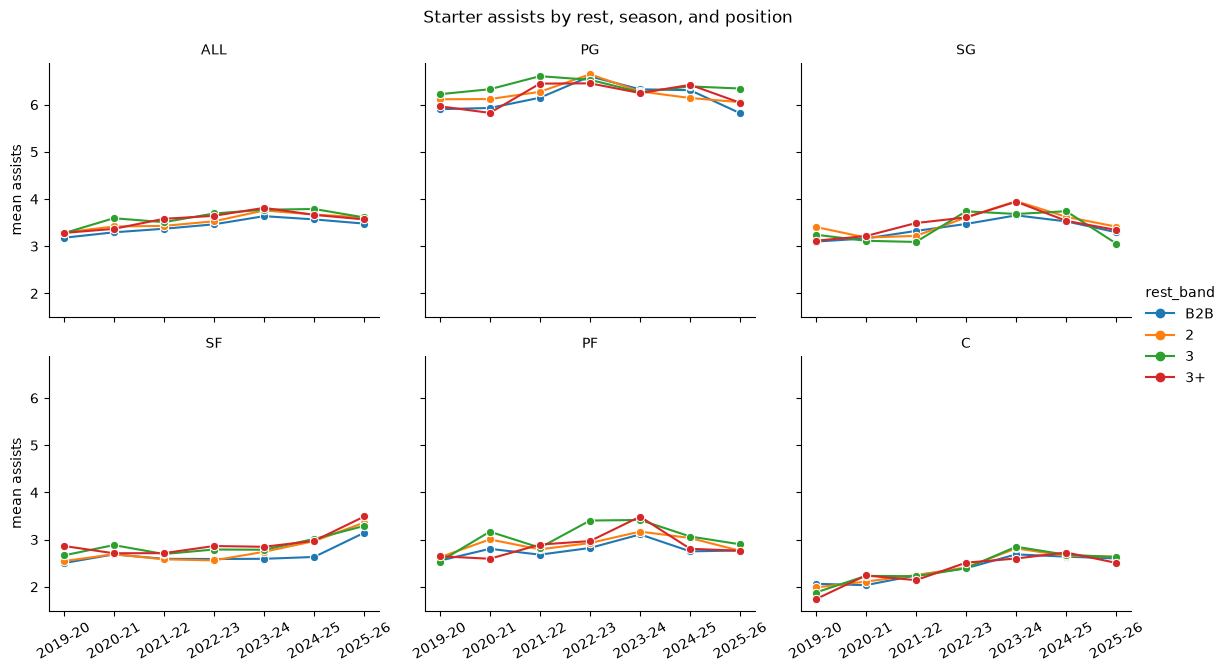

In [13]:
season_order = ["2019-20", "2020-21", "2021-22", "2022-23", "2023-24", "2024-25", "2025-26"]
starter_rest_year = starter_rest.assign(
    season_year=starter_rest["season_year"].astype("string"),
)
starter_rest_year = starter_rest_year.loc[
    starter_rest_year["season_year"].isin(season_order)
]

assists_by_year_rest = (
    starter_rest_year.groupby(
        ["season_year", "pos", "rest_band"],
        observed=False,
    )["ast"]
    .mean()
    .reset_index(name="mean")
)
overall_by_year_rest = (
    starter_rest_year.groupby(["season_year", "rest_band"], observed=False)["ast"]
    .mean()
    .reset_index(name="mean")
    .assign(pos="ALL")
)
means = (
    overall_by_year_rest.pivot(index="season_year", columns="rest_band", values="mean")
    .reindex(index=season_order, columns=rest_order)
)
display(means.round(2))

plot = pd.concat([overall_by_year_rest, assists_by_year_rest], ignore_index=True)
figure = sns.relplot(
    data=plot,
    x="season_year",
    y="mean",
    hue="rest_band",
    hue_order=rest_order,
    col="pos",
    col_order=["ALL", *pos_order],
    col_wrap=3,
    kind="line",
    marker="o",
    height=3.2,
    aspect=1.2,
)
figure.set_axis_labels("", "mean assists")
figure.set_titles("{col_name}")
figure.figure.suptitle(
    "Starter assists by rest, season, and position",
    y=1.03,
)
for ax in figure.axes.flatten():
    ax.tick_params(axis="x", rotation=30)
plt.show()

season_phase,before All-Star,after All-Star
pos,,
PG,6.27,6.19
SG,3.40,3.58
SF,2.78,2.84
PF,2.87,2.96
C,2.41,2.40


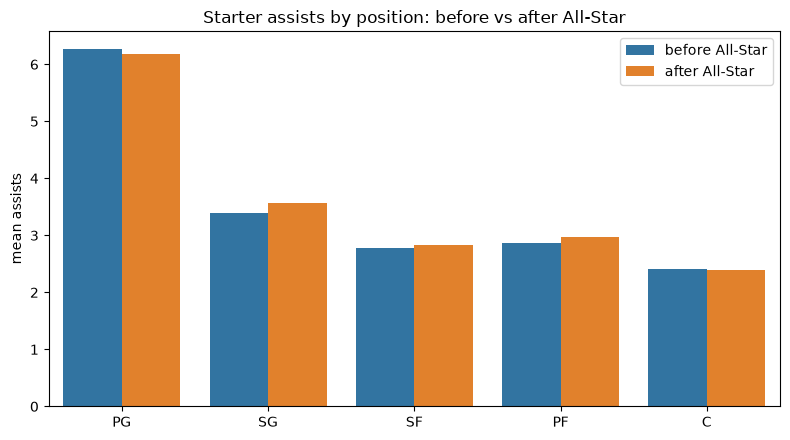

season_phase,before All-Star,after All-Star
rest_band,,
B2B,3.42,3.46
2,3.51,3.57
3,3.58,3.70
3+,3.61,3.52


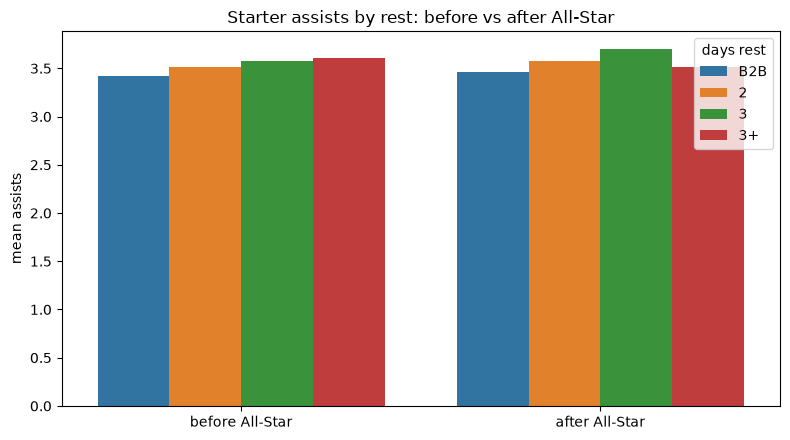

In [14]:
phase_order = ["before All-Star", "after All-Star"]
ALL_STAR_DATES = {
    "2019-20": pd.Timestamp("2020-02-16"),
    "2020-21": pd.Timestamp("2021-03-07"),
    "2021-22": pd.Timestamp("2022-02-20"),
    "2022-23": pd.Timestamp("2023-02-19"),
    "2023-24": pd.Timestamp("2024-02-18"),
    "2024-25": pd.Timestamp("2025-02-16"),
    "2025-26": pd.Timestamp("2026-02-15"),
}
game_date = pd.to_datetime(starter_rest["game_date"])
asb = starter_rest["season_year"].map(ALL_STAR_DATES)
starter_phase = starter_rest.assign(
    season_phase=np.select(
        [game_date.lt(asb), game_date.gt(asb)],
        phase_order,
        default="other",
    ),
)
starter_phase = starter_phase.loc[
    starter_phase["season_phase"].isin(phase_order)
]

assists_by_pos_phase = (
    starter_phase.groupby(["pos", "season_phase"], observed=False)["ast"]
    .agg(mean="mean", median="median", rows="size")
    .reset_index()
)
means_phase = (
    assists_by_pos_phase.pivot(index="pos", columns="season_phase", values="mean")
    .reindex(index=pos_order, columns=phase_order)
)
display(means_phase.round(2))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(
    data=assists_by_pos_phase,
    x="pos",
    y="mean",
    hue="season_phase",
    order=pos_order,
    hue_order=phase_order,
    ax=ax,
)
ax.set_title("Starter assists by position: before vs after All-Star")
ax.set_xlabel("")
ax.set_ylabel("mean assists")
ax.legend(title="")
plt.tight_layout()
plt.show()

assists_by_rest_phase = (
    starter_phase.groupby(["rest_band", "season_phase"], observed=False)["ast"]
    .mean()
    .reset_index(name="mean")
)
means_rest_phase = (
    assists_by_rest_phase.pivot(index="rest_band", columns="season_phase", values="mean")
    .reindex(index=rest_order, columns=phase_order)
)
display(means_rest_phase.round(2))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(
    data=assists_by_rest_phase,
    x="season_phase",
    y="mean",
    hue="rest_band",
    order=phase_order,
    hue_order=rest_order,
    ax=ax,
)
ax.set_title("Starter assists by rest: before vs after All-Star")
ax.set_xlabel("")
ax.set_ylabel("mean assists")
ax.legend(title="days rest")
plt.tight_layout()
plt.show()

### Now we'll explore bench players

In [15]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
bench_assists_by_pos = (
    bench.groupby("pos", dropna=False)["ast"]
    .describe()
    .T
    .reindex(columns=pos_order)
)
display(bench_assists_by_pos)

pos,PG,SG,SF,PF,C
count,15859.000000,25183.000000,17206.000000,18068.000000,17326.000000
mean,2.587868,1.498868,1.110833,1.020312,0.909154
std,2.337388,1.684462,1.386480,1.276332,1.183558
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,1.000000,1.000000,1.000000,1.000000
75%,4.000000,2.000000,2.000000,2.000000,1.000000
max,17.000000,15.000000,11.000000,11.000000,11.000000


### Bench assists by position and minutes

minute_band,"[0, 12)","[12, 18)","[18, 24)","[24, 30)","[30, 36)","[36, 64)"
count,31167.000000,22950.000000,22254.000000,12989.000000,3871.000000,411.000000
mean,0.443482,1.268889,1.907477,2.528909,3.208990,3.467153
std,0.762586,1.347240,1.749238,2.083830,2.423609,2.744532
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
50%,0.000000,1.000000,2.000000,2.000000,3.000000,3.000000
75%,1.000000,2.000000,3.000000,4.000000,4.500000,5.000000
max,8.000000,11.000000,15.000000,15.000000,15.000000,17.000000


minute_band,"[0, 12)","[12, 18)","[18, 24)","[24, 30)","[30, 36)","[36, 64)"
pos,,,,,,
PG,0.83,2.33,3.35,4.24,5.10,5.89
SG,0.45,1.25,1.88,2.53,3.15,3.37
SF,0.33,0.98,1.48,2.00,2.52,2.48
PF,0.34,0.93,1.41,1.83,2.37,2.25
C,0.35,0.98,1.42,1.78,2.10,2.00


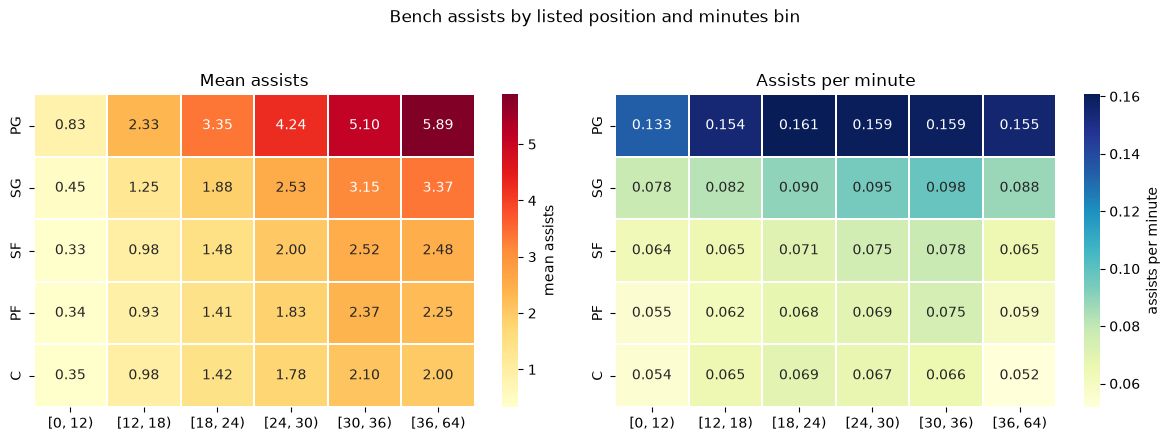

In [16]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
bench_minutes = bench.assign(
    pos=bench["pos"].astype("string"),
    minute_band=bench["minute_band"].astype("string"),
)
bench_minutes = bench_minutes.loc[
    bench_minutes["pos"].isin(pos_order)
    & bench_minutes["minute_band"].isin(MINUTE_LABELS)
]

bench_assists_by_minutes = (
    bench_minutes.groupby("minute_band", dropna=False)["ast"]
    .describe()
    .T
    .reindex(columns=MINUTE_LABELS)
)
assists_by_pos_minutes = (
    bench_minutes.groupby(["pos", "minute_band"], observed=False)["ast"]
    .mean()
    .unstack("minute_band")
    .reindex(index=pos_order, columns=MINUTE_LABELS)
)
rate_by_pos_minutes = (
    bench_minutes.groupby(["pos", "minute_band"], observed=False)["ast_per_min"]
    .mean()
    .unstack("minute_band")
    .reindex(index=pos_order, columns=MINUTE_LABELS)
)
display(bench_assists_by_minutes)
display(assists_by_pos_minutes.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.heatmap(
    assists_by_pos_minutes,
    ax=axes[0],
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    linewidths=0.3,
    cbar_kws={"label": "mean assists"},
)
axes[0].set_title("Mean assists")
axes[0].set_xlabel("")
axes[0].set_ylabel("")
sns.heatmap(
    rate_by_pos_minutes,
    ax=axes[1],
    cmap="YlGnBu",
    annot=True,
    fmt=".3f",
    linewidths=0.3,
    cbar_kws={"label": "assists per minute"},
)
axes[1].set_title("Assists per minute")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
fig.suptitle("Bench assists by listed position and minutes bin", y=1.04)
plt.tight_layout()
plt.show()

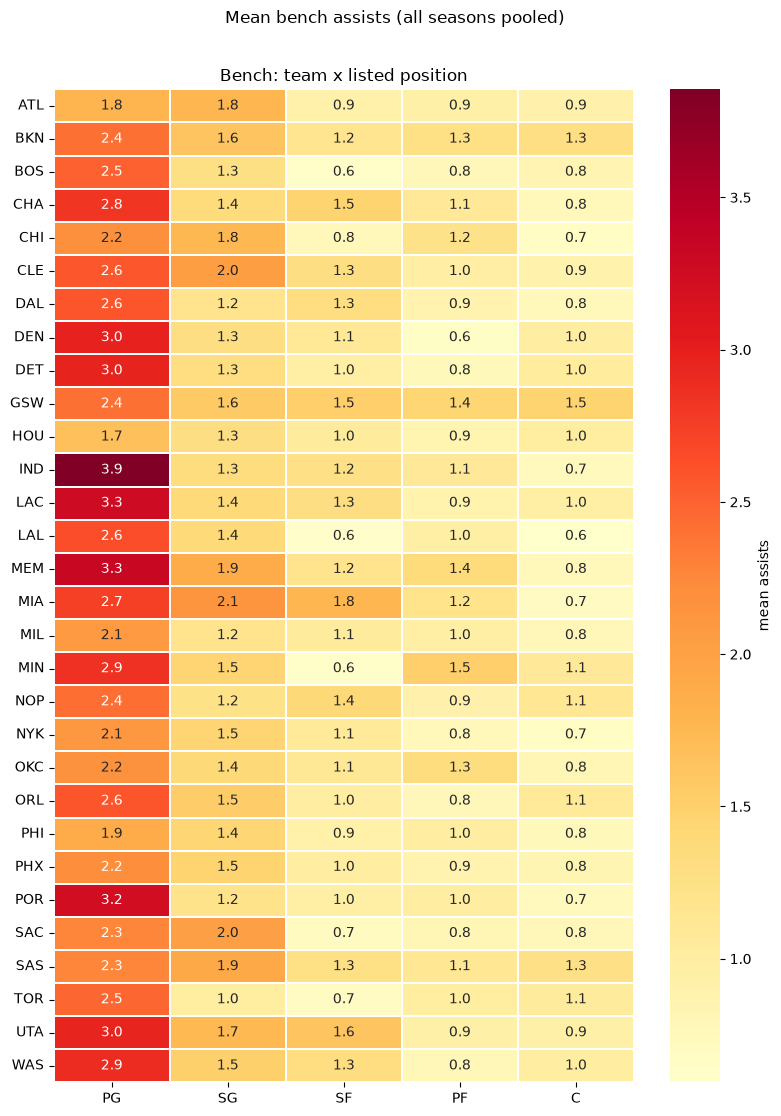

In [17]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
bench_pos = bench.assign(pos=bench["pos"].astype("string"))
assists_by_team_pos = (
    bench_pos.loc[bench_pos["pos"].isin(pos_order)]
    .groupby(["team_abbreviation", "pos"], observed=False)["ast"]
    .mean()
    .unstack("pos")
    .reindex(columns=pos_order)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(8, 11))
sns.heatmap(
    assists_by_team_pos,
    ax=ax,
    cmap="YlOrRd",
    annot=True,
    fmt=".1f",
    linewidths=0.3,
    cbar_kws={"label": "mean assists"},
)
ax.set_title("Bench: team x listed position")
ax.set_xlabel("")
ax.set_ylabel("")
fig.suptitle("Mean bench assists (all seasons pooled)", y=1.01)
plt.tight_layout()
plt.show()

spread_role,≤ -7.5,-7.5 to -3,-3 to 3.5,> 3.5
pos,,,,
PG,2.45,2.53,2.51,2.75
SG,1.50,1.47,1.45,1.55
SF,1.11,1.09,1.05,1.17
PF,1.00,0.98,0.98,1.09
C,0.88,0.85,0.88,0.97


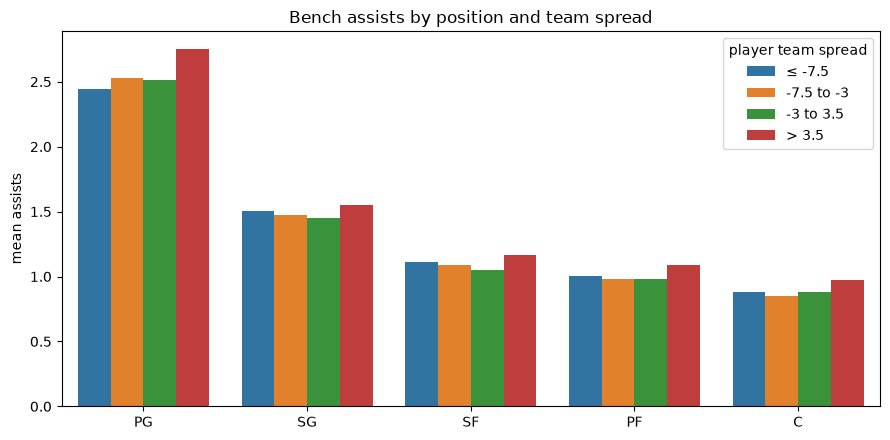

In [18]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
spread_order = ["≤ -7.5", "-7.5 to -3", "-3 to 3.5", "> 3.5"]
spread = pd.to_numeric(bench["player_team_spread"], errors="coerce")
bench_script = bench.assign(
    pos=bench["pos"].astype("string"),
    spread_role=pd.cut(
        spread,
        bins=[-np.inf, -7.5, -3, 3.5, np.inf],
        labels=spread_order,
        right=True,
    ).astype("string"),
)
bench_script = bench_script.loc[
    bench_script["pos"].isin(pos_order)
    & bench_script["spread_role"].isin(spread_order)
]

assists_by_pos_script = (
    bench_script.groupby(["pos", "spread_role"], observed=False)["ast"]
    .agg(mean="mean", median="median", rows="size")
    .reset_index()
)
means = (
    assists_by_pos_script.pivot(index="pos", columns="spread_role", values="mean")
    .reindex(index=pos_order, columns=spread_order)
)
display(means.round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(
    data=assists_by_pos_script,
    x="pos",
    y="mean",
    hue="spread_role",
    order=pos_order,
    hue_order=spread_order,
    ax=ax,
)
ax.set_title("Bench assists by position and team spread")
ax.set_xlabel("")
ax.set_ylabel("mean assists")
ax.legend(title="player team spread")
plt.tight_layout()
plt.show()

total_band,≤ 221,221–227,227.5–233.5,≥ 234
pos,,,,
PG,2.50,2.55,2.55,2.78
SG,1.46,1.48,1.48,1.58
SF,1.07,1.09,1.10,1.21
PF,1.00,1.01,1.03,1.05
C,0.87,0.90,0.92,0.95


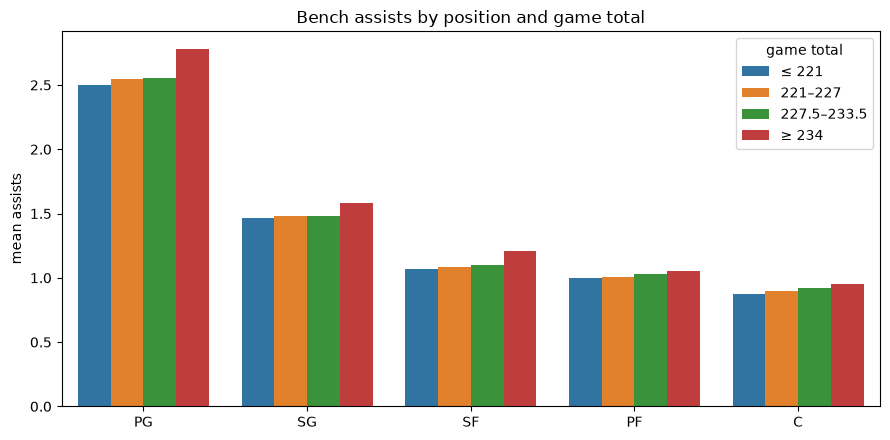

In [19]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
total_order = ["≤ 221", "221–227", "227.5–233.5", "≥ 234"]
game_total = pd.to_numeric(bench["game_total"], errors="coerce")
bench_total = bench.assign(
    pos=bench["pos"].astype("string"),
    total_band=pd.cut(
        game_total,
        bins=[-np.inf, 221, 227, 233.5, np.inf],
        labels=total_order,
        right=True,
    ).astype("string"),
)
bench_total = bench_total.loc[
    bench_total["pos"].isin(pos_order)
    & bench_total["total_band"].isin(total_order)
]

assists_by_pos_total = (
    bench_total.groupby(["pos", "total_band"], observed=False)["ast"]
    .agg(mean="mean", median="median", rows="size")
    .reset_index()
)
means = (
    assists_by_pos_total.pivot(index="pos", columns="total_band", values="mean")
    .reindex(index=pos_order, columns=total_order)
)
display(means.round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(
    data=assists_by_pos_total,
    x="pos",
    y="mean",
    hue="total_band",
    order=pos_order,
    hue_order=total_order,
    ax=ax,
)
ax.set_title("Bench assists by position and game total")
ax.set_xlabel("")
ax.set_ylabel("mean assists")
ax.legend(title="game total")
plt.tight_layout()
plt.show()

rest_band,B2B,2,3,3+
pos,,,,
PG,2.81,2.79,2.66,1.92
SG,1.65,1.62,1.56,1.09
SF,1.20,1.24,1.20,0.73
PF,1.10,1.13,1.04,0.71
C,1.00,0.99,0.97,0.66


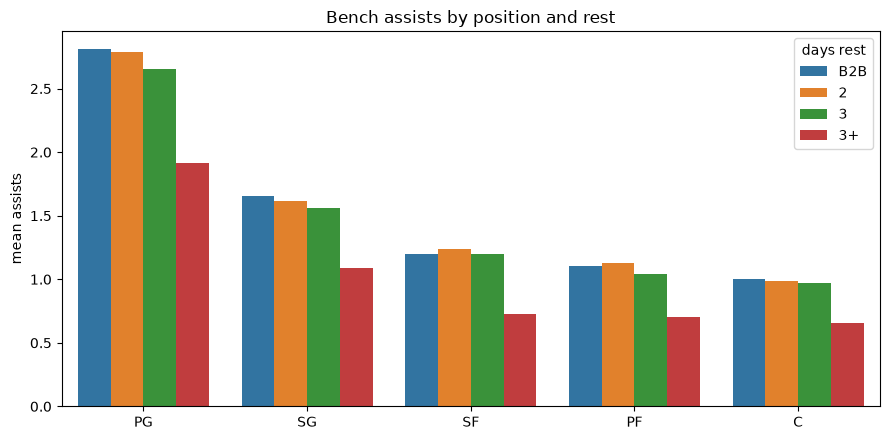

In [20]:
pos_order = ["PG", "SG", "SF", "PF", "C"]
rest_order = ["B2B", "2", "3", "3+"]
bench_rest = rest.loc[rest["starting"].eq(0)].assign(
    pos=lambda frame: frame["pos"].astype("string"),
)
bench_rest = bench_rest.loc[
    bench_rest["pos"].isin(pos_order)
    & bench_rest["rest_band"].isin(rest_order)
]

assists_by_pos_rest = (
    bench_rest.groupby(["pos", "rest_band"], observed=False)["ast"]
    .agg(mean="mean", median="median", rows="size")
    .reset_index()
)
means = (
    assists_by_pos_rest.pivot(index="pos", columns="rest_band", values="mean")
    .reindex(index=pos_order, columns=rest_order)
)
display(means.round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(
    data=assists_by_pos_rest,
    x="pos",
    y="mean",
    hue="rest_band",
    order=pos_order,
    hue_order=rest_order,
    ax=ax,
)
ax.set_title("Bench assists by position and rest")
ax.set_xlabel("")
ax.set_ylabel("mean assists")
ax.legend(title="days rest")
plt.tight_layout()
plt.show()

rest_band,B2B,2,3,3+
season_year,,,,
2019-20,1.61,1.58,1.45,1.02
2020-21,1.54,1.50,1.29,0.91
2021-22,1.44,1.45,1.41,0.94
2022-23,1.43,1.49,1.51,0.98
2023-24,1.55,1.55,1.47,0.95
2024-25,1.57,1.60,1.51,1.04
2025-26,1.70,1.63,1.62,1.10


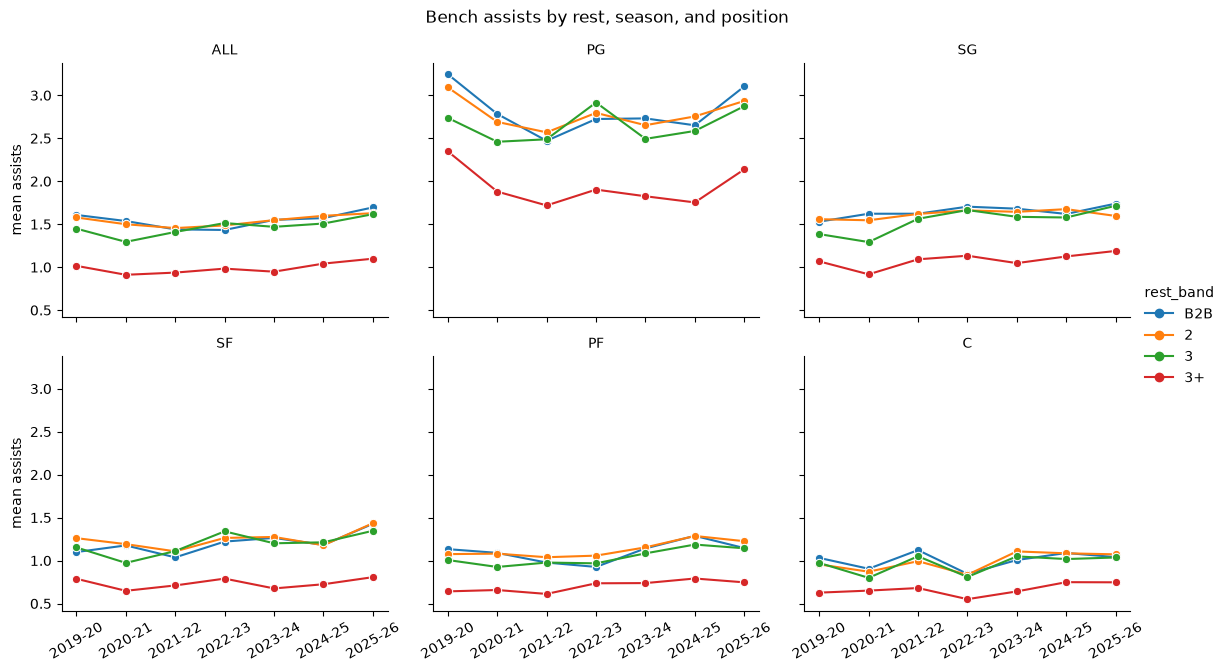

In [21]:
season_order = ["2019-20", "2020-21", "2021-22", "2022-23", "2023-24", "2024-25", "2025-26"]
bench_rest_year = bench_rest.assign(
    season_year=bench_rest["season_year"].astype("string"),
)
bench_rest_year = bench_rest_year.loc[
    bench_rest_year["season_year"].isin(season_order)
]

assists_by_year_rest = (
    bench_rest_year.groupby(
        ["season_year", "pos", "rest_band"],
        observed=False,
    )["ast"]
    .mean()
    .reset_index(name="mean")
)
overall_by_year_rest = (
    bench_rest_year.groupby(["season_year", "rest_band"], observed=False)["ast"]
    .mean()
    .reset_index(name="mean")
    .assign(pos="ALL")
)
means = (
    overall_by_year_rest.pivot(index="season_year", columns="rest_band", values="mean")
    .reindex(index=season_order, columns=rest_order)
)
display(means.round(2))

plot = pd.concat([overall_by_year_rest, assists_by_year_rest], ignore_index=True)
figure = sns.relplot(
    data=plot,
    x="season_year",
    y="mean",
    hue="rest_band",
    hue_order=rest_order,
    col="pos",
    col_order=["ALL", *pos_order],
    col_wrap=3,
    kind="line",
    marker="o",
    height=3.2,
    aspect=1.2,
)
figure.set_axis_labels("", "mean assists")
figure.set_titles("{col_name}")
figure.figure.suptitle(
    "Bench assists by rest, season, and position",
    y=1.03,
)
for ax in figure.axes.flatten():
    ax.tick_params(axis="x", rotation=30)
plt.show()

season_phase,before All-Star,after All-Star
pos,,
PG,2.60,2.63
SG,1.50,1.54
SF,1.10,1.17
PF,1.02,1.06
C,0.90,0.96


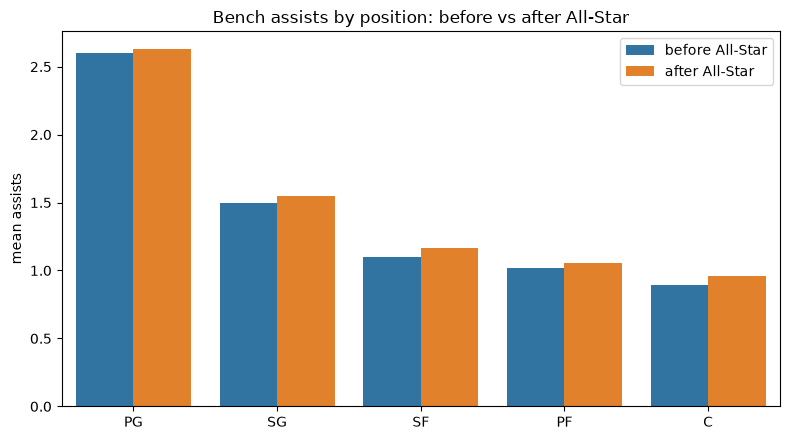

season_phase,before All-Star,after All-Star
rest_band,,
B2B,1.51,1.62
2,1.51,1.60
3,1.49,1.45
3+,0.97,1.03


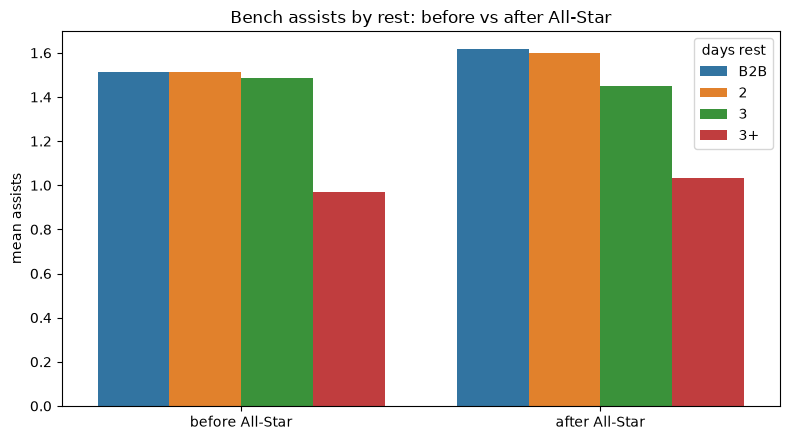

In [22]:
phase_order = ["before All-Star", "after All-Star"]
ALL_STAR_DATES = {
    "2019-20": pd.Timestamp("2020-02-16"),
    "2020-21": pd.Timestamp("2021-03-07"),
    "2021-22": pd.Timestamp("2022-02-20"),
    "2022-23": pd.Timestamp("2023-02-19"),
    "2023-24": pd.Timestamp("2024-02-18"),
    "2024-25": pd.Timestamp("2025-02-16"),
    "2025-26": pd.Timestamp("2026-02-15"),
}
game_date = pd.to_datetime(bench_rest["game_date"])
asb = bench_rest["season_year"].map(ALL_STAR_DATES)
bench_phase = bench_rest.assign(
    season_phase=np.select(
        [game_date.lt(asb), game_date.gt(asb)],
        phase_order,
        default="other",
    ),
)
bench_phase = bench_phase.loc[bench_phase["season_phase"].isin(phase_order)]

assists_by_pos_phase = (
    bench_phase.groupby(["pos", "season_phase"], observed=False)["ast"]
    .agg(mean="mean", median="median", rows="size")
    .reset_index()
)
means_phase = (
    assists_by_pos_phase.pivot(index="pos", columns="season_phase", values="mean")
    .reindex(index=pos_order, columns=phase_order)
)
display(means_phase.round(2))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(
    data=assists_by_pos_phase,
    x="pos",
    y="mean",
    hue="season_phase",
    order=pos_order,
    hue_order=phase_order,
    ax=ax,
)
ax.set_title("Bench assists by position: before vs after All-Star")
ax.set_xlabel("")
ax.set_ylabel("mean assists")
ax.legend(title="")
plt.tight_layout()
plt.show()

assists_by_rest_phase = (
    bench_phase.groupby(["rest_band", "season_phase"], observed=False)["ast"]
    .mean()
    .reset_index(name="mean")
)
means_rest_phase = (
    assists_by_rest_phase.pivot(index="rest_band", columns="season_phase", values="mean")
    .reindex(index=rest_order, columns=phase_order)
)
display(means_rest_phase.round(2))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(
    data=assists_by_rest_phase,
    x="season_phase",
    y="mean",
    hue="rest_band",
    order=phase_order,
    hue_order=rest_order,
    ax=ax,
)
ax.set_title("Bench assists by rest: before vs after All-Star")
ax.set_xlabel("")
ax.set_ylabel("mean assists")
ax.legend(title="days rest")
plt.tight_layout()
plt.show()